# Explore here

## PROYECTO 
Se quiere establecer el almacén de nuestra empresa en otra localización y necesitamos estimar el ritmo de las ventas, que desde la creacion de la empresa ha ido en aumento, para los proximos meses, a fin de proveer el espacio que necesitaremos.

In [1]:
import pandas as pd

df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv')

df.head()

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


* Se importa la libreria de pandas
* Se carga el conjunto de datos atraves del link https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv 
* Se presenta las cinco primeras filas y las columnas del conjunto de datos  

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    366 non-null    str    
 1   sales   366 non-null    float64
dtypes: float64(1), str(1)
memory usage: 5.8 KB


* Se obtiene la informacion de las 2 columnas la fecha la tiene como una linea de texto mientras que las ventas las tiene como numero 
* Se tienen 366 datos en cada columna 

In [3]:
df['date'] = pd.to_datetime(df['date'])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    366 non-null    datetime64[us]
 1   sales   366 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 5.8 KB


* Se convierte la columna date al tipo de dato datetime para manejarla como fecha 
* Se muestra la informacion de el tipo de dato, cantidad de no nulos y el uso de memoria 


In [4]:
df = df.set_index('date')

df.head()

,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693
2022-09-06 17:10:08.079328,64.530899
2022-09-07 17:10:08.079328,66.013633


* Se establece la columna date como el nuevo indice del dataframe para facilitar el analisis de series de tiempo
* Se muestra las cinco filas del data frame 

In [5]:
ts = df['sales']

ts.head()

date
2022-09-03 17:10:08.079328    55.292157
2022-09-04 17:10:08.079328    53.803211
2022-09-05 17:10:08.079328    58.141693
2022-09-06 17:10:08.079328    64.530899
2022-09-07 17:10:08.079328    66.013633
Name: sales, dtype: float64

* Se selecciona la columna sales del dataframe y la guarda en la variable ts como una serie de tiempo
* Se muestra las primeras cinco filas de la serie usando ts.head

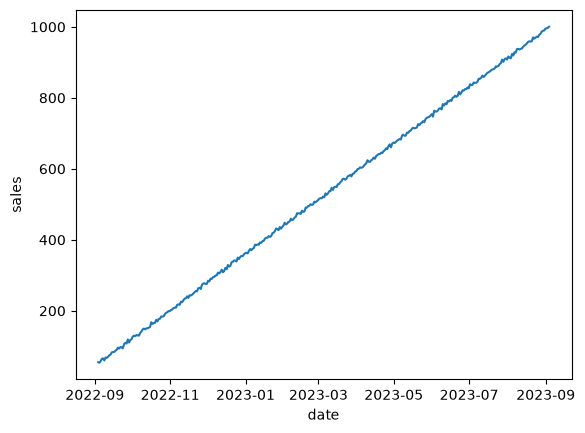

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(data=ts)

plt.show()

* Se importo la libreria matplotlib.pyplot y seaborn 
* Se genero un grafico de lineas usando la serie de tiempo ts para observar la tendencia de los datos
* Se muestra el grafico
* El eje x son las fechas desde septiemre 2022 hasta septiembre 2023 y el eje y son las ventas 
* Se trata de un grafico unidimensional 
* Tiene una tendencia creciente, donde las ventas crecen de forma continua durante todo el año 2022 al 2023 
* No es estacionaria porque esta las ventas aumneta 
* Tiene  muy poco ruido el grafico (dientes de sierra)



In [7]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


Se instala la libreria statsmodels

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

dp = seasonal_decompose(ts)
trend = dp.trend
seasonal = dp.seasonal
resid = dp.resid

* Se importa la funcion seasonal_decompose
* Se realiza la descomposicion de la serie de tiempo ts guardando el resultado en la variable dp
* Se extrae la componente de la tendencia y se almacena en la variable trend
* Se extrae la componente de la estacionalidad y se almacena en la variable seasonal
* Se extrae la componente de los residuos o ruido aleatorio y se almacena en la variable resid


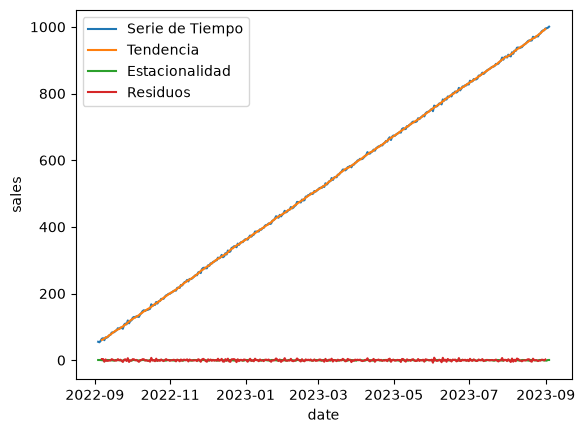

In [9]:
sns.lineplot(data=ts, label='Serie de Tiempo')
sns.lineplot(data=trend, label='Tendencia')
sns.lineplot(data=seasonal, label='Estacionalidad')
sns.lineplot(data=resid, label='Residuos')

plt.legend()
plt.show()

* Se grafica la serie de tiempo original junto con su tendencia, estacionalidad y residuos en un mismo grafico usando sns.lineplot y con la etiqueta para identificar la serie de tiempo, tendecia, estacionalidad y los residuos por colores diferentes

In [10]:
from statsmodels.tsa.stattools import adfuller

def test_stationary(timeseries):
    print('Resultados de la prueba de Dickey-Fuller')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index = ['Test Estadístico','p-value','#Lags usados','Número de Obs usadas'])
    for key, value in dftest[4].items():
        dfoutput[f'Valor Crítico {key}'] = value
    return dfoutput

test_stationary(ts)

Resultados de la prueba de Dickey-Fuller


Test Estadístico          0.545414
p-value                   0.986190
#Lags usados             13.000000
Número de Obs usadas    352.000000
Valor Crítico 1%         -3.449065
Valor Crítico 5%         -2.869786
Valor Crítico 10%        -2.571163
dtype: float64

* Se importa la funcion adfuller de la libreria statsmodels para realizar la prueba de Dickey-Fuller aumentada
* Se define la funcion test_stationary para evaluar y formatear los resultados de la prueba de estacionariedad
* Se ejecuta la prueba estadistica sobre la serie de tiempo ts y se organizan los resultados en una serie de pandas
* Se imprimen los estadisticos obtenidos demostrando un p-value de 0,986190 que confirma que la serie no es estacionaria

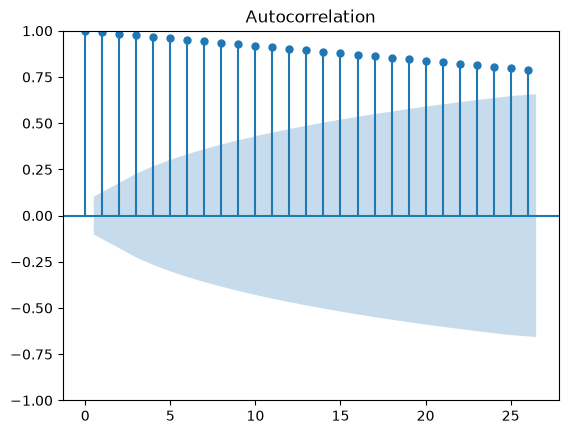

In [11]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(ts)

plt.show()

* Se importa la funcion plot_acf de la libreria statsmodels para calcular y visualizar la funcion de autocorrelacion
*Se muestra la correlación que existe entre el valor de las ventas en un día determinado y sus valores pasados a medida que nos alejamos en el tiempo (retardos o lags).
* Se observa que la autocorrelacion disminuye
    * Eje horizontal (X - Retardos / Lags): Representa el número de días hacia atrás (0, 5, 10, 15, 20, 25 días).
    * Eje vertical (Y - Correlación): Va de -1 a 1. Un valor cercano a 1 indica una correlación positiva muy fuerte.
    * Líneas azules con puntos: Es el valor de autocorrelación para cada retardo.
    * Área sombreada en azul: Es la zona de insignificancia estadística (intervalo de confianza del 95%).
        * Si la barra cae DENTRO del area azul: La correlación es tan débil que no debemos fiarnos de ella. Se considera ruido.
        * Si la barra sale FUERA del area azul: La correlacion es tan alta que imposible que sea por casualidad




In [12]:
%pip install pmdarima

Note: you may need to restart the kernel to use updated packages.


Se instala la libreria pmdarina

In [13]:
from pmdarima import auto_arima

model = auto_arima(ts,seasonal=False,trace=True,m=7)

c:\Users\veron\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pmdarima\arima\_validation.py:62: UserWarning: m (7) set for non-seasonal fit. Setting to 0
  warnings.warn("m (%i) set for non-seasonal fit. Setting to 0" % m)


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1843.274, Time=0.44 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2096.542, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1970.972, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1839.586, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2209.657, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1839.552, Time=0.18 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1841.532, Time=0.31 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1843.586, Time=0.15 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1839.607, Time=0.16 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1922.648, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=inf, Time=0.18 sec

Best model:  ARIMA(1,1,1)(0,0,0)[0] intercept
Total fit time: 1.702 seconds


* Se importa la funcion auto_arima
* Se ajusta el modelo auto_arima utilizando la serie de tiempo ts configurando seasonal en False para omitir la componente estacional 
* Se activa el parametro trace en True para mostrar en pantalla la evaluacion de los distintos modelos probados durante el proceso
* Se especifica el parametro m en 7 para definir la frecuencia del ciclo semanal
* Se ejecuta una busqueda por pasos para evaluar diferentes combinaciones de modelos ARIMA
* Se realiza una diferenciacion automatica (d=1) en los datos para corregir la falta de estacionariedad observada previamente
* Se comparan multiples configuraciones del modelo mostrando la metrica AIC
* Se selecciona como el mejor modelo la configuracion ARIMA(1,1,1)


In [14]:
forecast = model.predict(90)
forecast

2023-09-04 17:10:08.079328    1002.158148
2023-09-05 17:10:08.079328    1004.831669
2023-09-06 17:10:08.079328    1007.423289
2023-09-07 17:10:08.079328    1010.021630
2023-09-08 17:10:08.079328    1012.619419
                                 ...     
2023-11-28 17:10:08.079328    1223.043737
2023-11-29 17:10:08.079328    1225.641568
2023-11-30 17:10:08.079328    1228.239399
2023-12-01 17:10:08.079328    1230.837230
2023-12-02 17:10:08.079328    1233.435061
Freq: D, Length: 90, dtype: float64

* Se genera el pronóstico de ventas proyectado a 90 días futuros utilizando el método predict del modelo ARIMA
* Se almacena la serie temporal predicha en la variable forecast con su correspondiente índice de fechas proyectado
* Se despliegan en pantalla las estimaciones calculadas, mostrando una proyección que continúa con la tendencia alcista desde un valor inicial de 1002,158148 el 04/09/2023 hasta alcanzar 1233,435061 el 02/12/2023


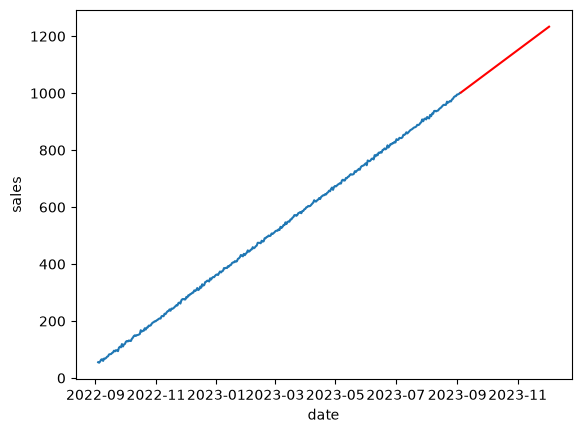

In [15]:
sns.lineplot(data=ts)
sns.lineplot(data=forecast,c='red')
plt.show()

* Se visualiza la serie de tiempo original ts junto con sus proyecciones futuras almacenadas en forecast dentro del mismo grafico 
* Se aplica el color rojo a la linea de la prediccion mediante el parametro c='red'
* Se muestra el grafico final en pantalla con plt.show()



In [16]:
import joblib

joblib.dump(model, '../models/auto_arima.pkl')

['../models/auto_arima.pkl']

In [17]:
from pickle import dump

dump(model,open('../models/auto_arima_pickle.model','wb'))